In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
root = "/kaggle/input/ocr-gsv-pytesseract/"

In [5]:
import os

gcv = pd.read_csv(root+"gcv-ocr.csv")
pyt = pd.read_csv(root+"pyt-ocr.csv")

In [6]:
gcv.head()

,filename,filepath,text-detected,OCR,coordinates,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,NaN,[],negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,NaN,[],negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative


In [7]:
pyt.head()

,filename,filepath,text-detected,OCR,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,fStop Wak\niv UKRATNE Po\n\nConte Yxpaini |\n\n,negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,NEW ee V\nNIGHTLY ATS =e ord a.\n,negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,NaN,negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,NaN,negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,NEW ee V\nNIGHTLY ATS =e ord a.\n,negative


In [8]:
pyt_td = pyt['text-detected']
gcv_td = gcv['text-detected']

In [9]:
len(gcv_td)

2875

In [10]:
gcv_td.loc[0]

1

In [11]:
l = len(gcv_td)

# tp,tn,fp,fn = 0,0,0,0
matches,gcv_detected,pyt_detected=0,0,0

for i in range(l):
    one = gcv_td.loc[i]
    two = pyt_td.loc[i]
    gcv_detected+=1 if one==1 else 0
    pyt_detected+=1 if two==1 else 0
    matches+=1 if one==two else 0

print(matches)


2178


In [12]:
print(f"#Text_Detections using Google Cloud Vision OCR API = {gcv_detected}")
print(f"#Text_Detections using PyTesseract = {pyt_detected}")

#Text_Detections using Google Cloud Vision OCR API = 2749
#Text_Detections using PyTesseract = 2058


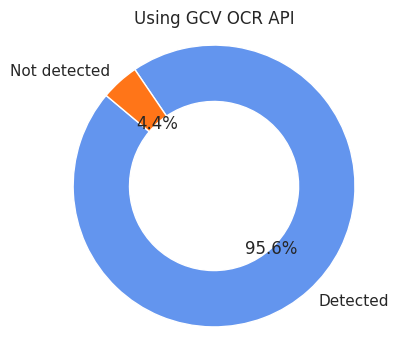

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

total = len(gcv_td)
labels = ["Detected", "Not detected"]

colors = ["#6395EE", "#FF7518"]
sns.set_theme(style="whitegrid")
values = [gcv_detected, total-gcv_detected]

plt.figure(figsize=(4,4))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,  wedgeprops={'width': 0.4})
plt.title('Using GCV OCR API')
plt.axis('equal')

plt.savefig("gcv_td_tnd.png", dpi=300, bbox_inches='tight')

plt.show()

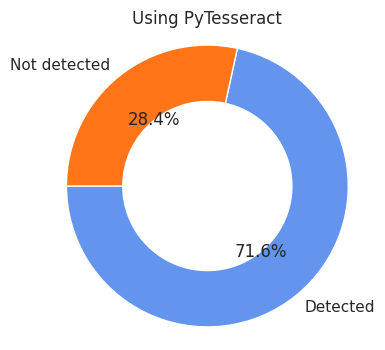

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

total = len(gcv_td)
labels = ["Detected", "Not detected"]

# colors = ['#e74c3c', '#3498db']
colors = ["#6395EE", "#FF7518"]
sns.set_theme(style="whitegrid")
values = [pyt_detected, total-pyt_detected]

plt.figure(figsize=(4,4))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=180, colors=colors, wedgeprops={"width":0.4})
plt.title('Using PyTesseract')
plt.axis('equal')

plt.savefig("pyt_td_tnd.png", dpi=300, bbox_inches='tight')

plt.show()

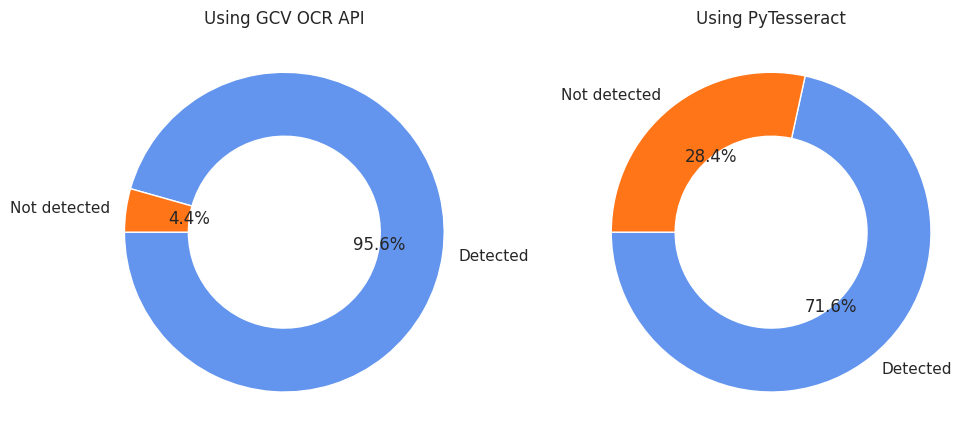

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

total = len(gcv_td)
labels = ["Detected", "Not detected"]

# colors = ['#e74c3c', '#3498db']
colors = ["#6395EE", "#FF7518"]
sns.set_theme(style="whitegrid")
values2 = [pyt_detected, total-pyt_detected]
values1 = [gcv_detected, total-gcv_detected]


# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,20))

# Pie chart 1
ax1.pie(values1, labels=labels, startangle=180, wedgeprops={"width":0.4},autopct='%1.1f%%', colors=colors)
ax1.set_title("Using GCV OCR API")

# Pie chart 2
ax2.pie(values2, labels=labels, startangle=180, wedgeprops={"width":0.4}, autopct='%1.1f%%', colors=colors)
ax2.set_title("Using PyTesseract")

plt.savefig("gcv-pyt_td_tnd.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()